# AG-HYPOPT · Trial 25

> ▶ RUN = execute this cell, never modify it  ·  ✍️ WRITE = replace the [placeholder] with your text  ·  ✍️ SET = put your value where the [placeholder] is, then run the cell. Full rules: `instructions.md`


## 1. ✍️ WRITE - Read and summarize

Read `context.md` (physics/model knowledge). If there are previous trials, read them too
(all `trial_XX` notebooks numbered lower than this one) and `trials.json` (the registry).
The current best is the recorded trial with the lowest objective; it is the reference
for the cell-3 choice.

Twenty-four trials are recorded. Best is trial_07 (sw 0.865, h_f 4.0, h_s 3.675, cap 0.107) at 0.0803. Then trial_20 0.0821, trial_05 0.0822, trial_09 0.0839, trial_18 0.0844, trial_16 0.0850, trial_21 0.0852, trial_22 0.0853, trial_11 0.0859, trial_17 0.0859, trial_06 0.0861, ... trial_24 0.0871, ... up to trial_10 0.0922. All 0 diverged, gamma finite. The objective is sharply sensitive: near-replicas of both trial_07 (trials 17, 23) and trial_20 (trial_24) fell well short, so trial_07's 0.0803 is an isolated point. Phase 'trials'.


In [ ]:
# 2. ▶ RUN - Propose candidate trials (AGHyperopt)
TRIAL_ID = 'trial_25'   # auto-stamped by the generator; do not edit
import os

EXPERIMENT_DIR = os.getcwd()
SPACE_PATH = os.path.join(EXPERIMENT_DIR, 'space.json')
TRIALS_PATH = os.path.join(EXPERIMENT_DIR, 'trials.json')

MAX_TRIALS = 30    # campaign cap: stop generating new trials after this many (None = unlimited)

from ag_hypopt import AGHyperopt, trial_seed

opt = AGHyperopt(seed=trial_seed(TRIAL_ID))   # per-trial seed: fresh draws every trial
opt.fit(SPACE_PATH, TRIALS_PATH)
proposed_trials = opt.propose_trials(10)


phase = trials  (24/5 trials)
ID |     ei | params
 1 | 0.5189 | {"gamma_rel_cap": 0.10717657802534905, "h_f_scale": 3.9137225034782146, "h_s_scale": 0.9740608013785043, "sigma_weight": 0.8089712176652045}
 2 | 3.7979 | {"gamma_rel_cap": 0.11288565760506719, "h_f_scale": 3.9943084872370562, "h_s_scale": 3.6117976675899284, "sigma_weight": 0.9486940815196936}
 3 | 3.8441 | {"gamma_rel_cap": 0.13853504812599024, "h_f_scale": 3.9791921167855935, "h_s_scale": 3.615708550114597, "sigma_weight": 0.9732620546208859}
 4 | 3.8905 | {"gamma_rel_cap": 0.21796267739189867, "h_f_scale": 3.949672273247696, "h_s_scale": 3.6190958233443817, "sigma_weight": 0.9720116980365028}
 5 | 1.5971 | {"gamma_rel_cap": 0.16582904510197088, "h_f_scale": 0.6153335321124972, "h_s_scale": 3.6679510843632124, "sigma_weight": 0.9273024797593514}
 6 | 3.1213 | {"gamma_rel_cap": 0.3160289212034556, "h_f_scale": 4.0, "h_s_scale": 3.6338881227295943, "sigma_weight": 0.9571351620675094}
 7 | 0.4823 | {"gamma_rel_cap": 0.294

## 3. ✍️ WRITE - Analyze and choose

Using the summary from cell 1 (previous trials + registry) and the candidate table from
cell 2, choose the ONE proposal that makes the most sense for the next trial. No hypothesis
and no expectation are needed: base the choice on what the trials have shown and on the
candidates themselves.

trial_07 (0.0803) is an isolated sharp optimum and the objective is very sensitive to small changes. The batch again proposes a tight cluster of very high sigma weights (0.95-0.97) with flat kernels.

Candidate 4 (ei 3.8905, the highest) has sw 0.972, h_f 3.950, h_s 3.619 and a cap of 0.218 - the same cap band as trial_20, the best reproducible design (sw 0.922, cap 0.203 -> 0.0821). It pushes the sigma weight a little higher than trial_20 while keeping the cap in the band that design prefers; ids 2/3 use the same high sw but sit at the smaller caps already shown to be worse for high sw (trial_21).

I choose candidate 4.


In [ ]:
# 4. ✍️ SET - Chosen candidate (edit INDEX below, then run this cell)
INDEX = 4               # candidate 4: sigma_weight 0.972, h_f_scale 3.950, h_s_scale 3.619, gamma_rel_cap 0.218 (high sw, trial_20-like cap)


chosen: {'gamma_rel_cap': 0.21796267739189867, 'h_f_scale': 3.949672273247696, 'h_s_scale': 3.6190958233443817, 'sigma_weight': 0.9720116980365028}
Running  1nW Trans05 ... 

μ 9.39 -> 5.99 | γ 8.5 -> 4.85 | NLL 0.28


Running  1nW Trans20 ... 

μ 17.32 -> 27.71 | γ 8.5 -> 5.45 | NLL 0.69


Running  1nW Trans60 ... 

...

Running  3nW Trans60 ... 

μ 103.20 -> 61.74 | γ 14.1 -> 13.97 | NLL 0.73


Running 3nW Trans100 ... 

μ 175.71 -> 98.57 | γ 14.1 -> 13.76 | NLL 0.69



Total: 7.7 min


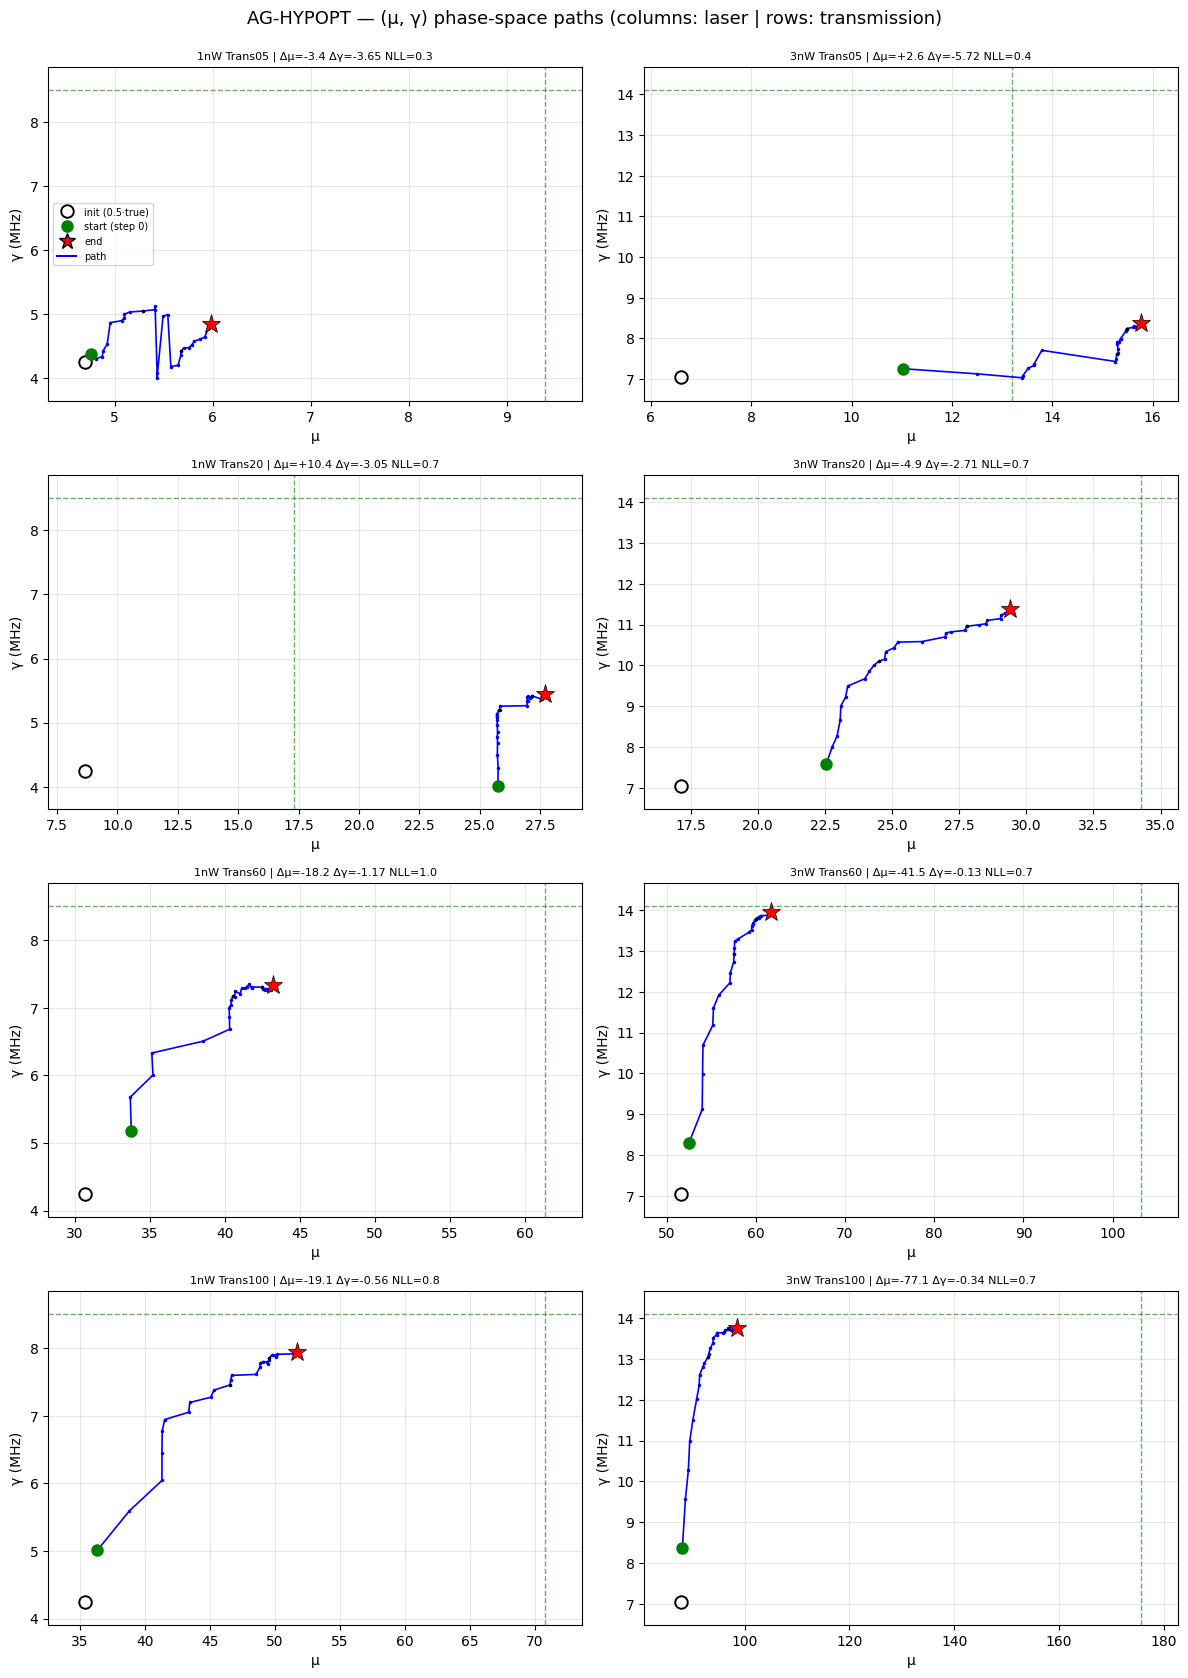

trial finished in 7.8 min
objective = 0.0865 ± 0.0245
exp              μ_true   μ_fit     Δμ% |   γ_true   γ_fit     Δγ%
1nW Trans05        9.39    5.99   -36.3 |     8.50    4.85   -42.9
1nW Trans20       17.32   27.71   +60.0 |     8.50    5.45   -35.9
1nW Trans60       61.37   43.19   -29.6 |     8.50    7.33   -13.7
1nW Trans100       70.82   51.69   -27.0 |     8.50    7.94    -6.6
3nW Trans05       13.20   15.77   +19.4 |    14.10    8.38   -40.6
3nW Trans20       34.28   29.40   -14.2 |    14.10   11.39   -19.2
3nW Trans60      103.20   61.74   -40.2 |    14.10   13.97    -0.9
3nW Trans100      175.71   98.57   -43.9 |    14.10   13.76    -2.4

weighted objective (T-graded, cap=1.0) = 0.0865 | diverged cells: 0
μ: RMSE 32.625 (rel 36.5%, bias -18.903) | γ: RMSE 2.840 (rel 25.9%, bias -2.166)


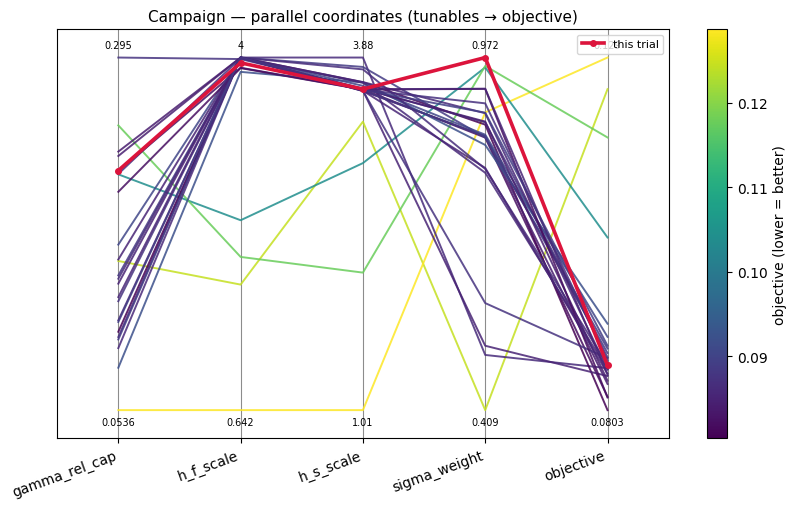

In [ ]:
# 5. ▶ RUN - Execute the chosen trial  (do not interrupt unless obviously broken)
assert INDEX is not None, 'INDEX not set: edit the SET cell (cell 4) before running this one'
assert 1 <= INDEX <= len(proposed_trials), f'bad INDEX: {INDEX}'
CHOSEN = proposed_trials[INDEX - 1]['params']
print('chosen:', CHOSEN)

from ag_hypopt import objective

import traceback, time
t0 = time.time()
try:
    loss, uncertainty, report = objective(CHOSEN)
    print(f'trial finished in {(time.time()-t0)/60:.1f} min')
    print(f'objective = {loss:.4f} ± {uncertainty:.4f}')
    print(report)
except Exception:
    traceback.print_exc()
    loss, uncertainty = None, None

# parallel coordinates: every recorded trial + this one (color = objective)
from ag_hypopt import plot_parallel
if loss is not None:
    plot_parallel(TRIALS_PATH, current={'config': CHOSEN, 'objective': loss})


## 6. ✍️ WRITE - Analyze the results

Record what actually happened in this trial: the measured objective, how the chosen
configuration behaved, and how that compares with the previous trials. No hypothesis to
confirm or refute, and no expectation to check: just the facts.

Trial 25 (sw 0.972, h_f 3.950, h_s 3.619, cap 0.218) ran to completion in 7.8 min with 0 diverged cells and gamma finite on all 8 cells; objective 0.0865 +/- 0.0245 - worse than trial_07 (0.0803) and trial_20 (0.0821), matching trial_15's value (0.0865).

mu rel-RMSE 36.5% (worse than trial_07's 35.9%): same shape - high-T undershoot (3nW Trans100 -43.9%, 3nW Trans60 -40.2%, 1nW Trans60 -29.6%, 1nW Trans100 -27.0%), low-T overshoot (1nW Trans20 +60.0%, 3nW Trans05 +19.4%); bias -18.90.

gamma rel-RMSE 25.9% (worse than trial_07's 22.3%): low T under-estimated (1nW Trans05 -42.9%, 3nW Trans05 -40.6%, 1nW Trans20 -35.9%), high T near truth (-0.9%, -2.4%).

The candidate raised the sigma weight to 0.972 (above both successful trials) with flat kernels and a trial_20-like cap; it landed at 0.0865, worse than trial_20's 0.0821 at sw 0.922. So the sigma-weight optimum is interior, near ~0.87-0.92, and pushing it higher degrades the result.

**Summary:** Trial 25 (sw=0.972, h_f=3.950, h_s=3.619, cap=0.218) finished in 7.8 min with 0 diverged cells and gamma finite, objective 0.0865 +/- 0.0245 - worse than trial_07 and trial_20 (mu rel-RMSE 36.5%, gamma rel-RMSE 25.9%).
**Key insight:** Very high sigma weight (0.972) with a trial_20-like cap gave 0.0865, worse than trial_20's 0.0821 at sw 0.922; the sigma-weight optimum is interior, near ~0.87-0.92.

Structural-change proposals (score, likelihood, model, protocol) belong here as notes for
Anuar: describe them, never act on them, never stop the campaign because of them.
Notes for Anuar: none (no structural-change proposals).


In [ ]:
# 7. ✍️ SET - Summary and key insight for the record (edit the strings below, then run)
SUMMARY = 'Trial 25 (sw=0.972, h_f=3.950, h_s=3.619, cap=0.218): objective 0.0865 +/- 0.0245 - worse than trial_07 and trial_20; 0 diverged cells, gamma finite (mu rel-RMSE 36.5%, gamma rel-RMSE 25.9%).'
KEY_INSIGHT = 'Very high sigma weight (0.972) with a trial_20-like cap gave 0.0865, worse than trial_20 0.0821 at sw 0.922; the sigma-weight optimum is interior, near ~0.87-0.92.'


In [ ]:
# 8. ▶ RUN - Record the trial in trials.json
import json

assert SUMMARY is not None, 'SUMMARY not set: fill the SET cell (cell 7) first'
assert KEY_INSIGHT is not None, 'KEY_INSIGHT not set: fill the SET cell (cell 7) first'

entry = {
    'trial_id': TRIAL_ID,
    'config': CHOSEN,
    'objective': loss,
    'uncertainty': uncertainty,
    'summary': SUMMARY,
    'key_insight': KEY_INSIGHT,
    'notebook': f'{TRIAL_ID}.ipynb',
}
data = json.load(open(TRIALS_PATH))
assert not any(t.get('trial_id') == TRIAL_ID for t in data['trials']),     f'{TRIAL_ID} is already registered in trials.json'
data['trials'].append(entry)
json.dump(data, open(TRIALS_PATH, 'w'), indent=2)
best = min((t for t in data['trials'] if t.get('objective') is not None),
           key=lambda t: t['objective'], default=None)
print('saved', TRIAL_ID, '| current best:', best['trial_id'] if best else None)


saved trial_25 | current best: trial_07


In [ ]:
# 9. ▶ RUN - Generate the next trial (or end the campaign)
import os, re, json as _json

num = int(re.search(r'(\d+)$', TRIAL_ID).group(1))
nxt = num + 1
if MAX_TRIALS is not None and nxt > MAX_TRIALS:
    print(f'Campaign complete: cap MAX_TRIALS={MAX_TRIALS} reached after {TRIAL_ID}. Stop here.')
else:
    template_path = os.path.join(EXPERIMENT_DIR, 'template.ipynb')
    target = os.path.join(EXPERIMENT_DIR, f'trial_{nxt:02d}.ipynb')
    assert not os.path.exists(target), f'{target} already exists: refusing to overwrite'

    nb = _json.load(open(template_path))

    def _stamp(old, new):
        for c in nb['cells']:
            if old in ''.join(c.get('source', [])):
                c['source'] = [s.replace(old, new) for s in c['source']]
                return True
        raise RuntimeError(f'stamp target {old!r} not found in the template')

    _stamp('{N}', f'{nxt:02d}')
    _stamp('trial_XXX', f'trial_{nxt:02d}')
    _json.dump(nb, open(target, 'w'), indent=1)
    print(f'Created {os.path.basename(target)}. Open it and follow its cells from the top.')


Created trial_26.ipynb. Open it and follow its cells from the top.
